In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

TESTO_DIR = "/content/drive/MyDrive/HERO/key_results_testi"

Mounted at /content/drive


In [ ]:
pip install sentence-transformers umap-learn hdbscan -q

In [ ]:
import os
import re
import json
import numpy as np
from sentence_transformers import SentenceTransformer
import umap
import pandas as pd

# ============================================================
# CONFIGURAZIONE
# ============================================================
MODEL_NAME = "BAAI/bge-m3"  # 8192 dim

# ============================================================
# CARICA MODELLO
# ============================================================
print(f"Caricamento modello {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)
print("Modello caricato.")



Caricamento modello BAAI/bge-m3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Modello caricato.


In [ ]:
# ============================================================
# FUNZIONE: ESTRAI METADATA DAL NOME FILE
# ============================================================
def estrai_metadata(nome_file):
    base = nome_file.replace("_KeyResults.txt", "")

    # Cerca il pattern mese_anno_-_mese_anno
    periodo_match = re.search(r'([A-Za-z]{3}_\d{4})_-_([A-Za-z]{3}_\d{4})', base)

    if periodo_match:
        inizio_periodo = periodo_match.group(1).replace('_', ' ')  # es. "Apr 2017"
        fine_periodo = periodo_match.group(2).replace('_', ' ')    # es. "Sep 2017"
        periodo = f"{inizio_periodo} / {fine_periodo}"
    else:
        inizio_periodo = None
        fine_periodo = None
        periodo = base

    # Paese: tutto quello che precede il primo mese
    paese_match = re.match(r'^(.+?)_[A-Za-z]{3}_\d{4}', base)
    paese = paese_match.group(1).replace('_', ' ') if paese_match else base

    return {
        "paese": paese,
        "periodo": periodo,
        "inizio_periodo": inizio_periodo,  # es. "Apr 2017"
        "fine_periodo": fine_periodo,       # es. "Sep 2017"
        "nome_file": nome_file
    }

In [ ]:
# ============================================================
# GENERA EMBEDDING
# ============================================================
N_COMPONENTS_PCA = 50  # dimensioni finali per clustering
files = [f for f in os.listdir(TESTO_DIR) if f.endswith(".txt")]
print(f"Trovati {len(files)} file...")

testi = []
metadata_list = []

for nome_file in files:
    path = os.path.join(TESTO_DIR, nome_file)
    with open(path, "r", encoding="utf-8") as f:
        testo = f.read()

    testo_pulito = re.sub(r'^.*?={40}\n\n', '', testo, flags=re.DOTALL).strip()
    if not testo_pulito:
        continue

    testi.append(testo_pulito)
    metadata_list.append(estrai_metadata(nome_file))

print(f"Generazione embedding per {len(testi)} documenti...")
# Modificato inserendo truncate_dim=128 per attivare la riduzione a 128 componenti del modello bge-m3
embeddings = model.encode(testi, truncate_dim=128, normalize_embeddings=True, show_progress_bar=True)
print(f"Embedding generati: shape {embeddings.shape}")


Trovati 497 file...
Generazione embedding per 497 documenti...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# DataFrame metadata
df = pd.DataFrame(metadata_list)
df["testo"] = testi

In [ ]:
# RIDUZIONE CON PCA

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import spearmanr

# 1. APPLICAZIONE DELLA PCA A 50 DIMENSIONI
# Riduciamo gli 'embeddings' originali a 50 componenti lineari
pca_50d = PCA(n_components=50, random_state=42)
embeddings_reduced_pca = pca_50d.fit_transform(embeddings)

print(f"Riduzione completata. Nuova shape (PCA): {embeddings_reduced_pca.shape}")
# Mostra quanta informazione originale (varianza) è stata catturata dalle 50 componenti
varianza_spiegata = np.sum(pca_50d.explained_variance_ratio_) * 100
print(f"Varianza totale preservata dalle 50 componenti PCA: {varianza_spiegata:.1f}%")

# 2. TEST DI COMPRESSIONE GEOMETRICA (VERIFICA DELLO STRESS)
print("\nCalcolo delle matrici di similarità coseno per la verifica...")
sim_originale = cosine_similarity(embeddings)
sim_compressa_pca = cosine_similarity(embeddings_reduced_pca)

dist_originale = euclidean_distances(embeddings)
dist_compressa_pca = euclidean_distances(embeddings_reduced_pca)

# Estraiamo solo il triangolo superiore delle matrici (escludendo la diagonale principale)
indici_sup = np.triu_indices(len(df), k=1)
vett_sim_orig = sim_originale[indici_sup]
vett_sim_comp_pca = sim_compressa_pca[indici_sup]

vett_dist_orig = dist_originale[indici_sup]
vett_dist_comp_pca = dist_compressa_pca[indici_sup]

# Calcolo della correlazione di Spearman
correlazione_pca, _ = spearmanr(vett_sim_orig, vett_sim_comp_pca)

correucl_pca, _ = spearmanr(vett_dist_orig, vett_dist_comp_pca)

# Verifica locale: Intersezione dei primi 10 vicini
N_vicini = 10
intersezioni_totali = []

for idx in range(len(df)):
    vicini_orig = np.argsort(sim_originale[idx])[:-1-N_vicini:-1]
    vicini_comp_pca = np.argsort(sim_compressa_pca[idx])[:-1-N_vicini:-1]
    comuni = len(set(vicini_orig).intersection(set(vicini_comp_pca)))
    intersezioni_totali.append(comuni)

percentuale_mantenimento_pca = (np.mean(intersezioni_totali) / N_vicini) * 100

# 3. REPORT FINALE PCA
print("\n================ REPORT DI COMPRESSIONE GEOMETRICA (PCA) ================")
print(f"1. Correlazione d'ordine globale (Spearman): {correlazione_pca:.4f}, {correucl_pca}")
print(f"2. Conservazione locale dei primi {N_vicini} vicini: {percentuale_mantenimento_pca:.1f}%")
print("=========================================================================")


Riduzione completata. Nuova shape (PCA): (497, 50)
Varianza totale preservata dalle 50 componenti PCA: 100.0%

Calcolo delle matrici di similarità coseno per la verifica...

================ REPORT DI COMPRESSIONE GEOMETRICA (PCA) ================
1. Correlazione d'ordine globale (Spearman): 1.0000, 0.9999999999736401
2. Conservazione locale dei primi 10 vicini: 99.9%


In [ ]:
# verifica similarità embedding prodotti

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Scegli l'indice del documento "Ancora" (es. il documento numero 10, cambialo a piacimento)
idx_ancora = 28

# 2. Calcola la similarità coseno tra il documento scelto e TUTTI gli altri nel dataset
# Lavoriamo sullo spazio a 50 dimensioni ridotte
vettore_ancora = embeddings_reduced_pca[idx_ancora].reshape(1, -1)
similarita = cosine_similarity(vettore_ancora, embeddings_reduced_pca).flatten()

# 3. Prendi gli indici dei primi 6 documenti più simili (il primo sarà il documento stesso, con similarità 1.0)
# ordinamento ascendente, prendiamo gli ultimi 6 elementi e invertiamo l'ordine
indici_top5 = np.argsort(similarita)[-6:-1][::-1]

# 4. STAMPA IL CONFRONTO QUALITATIVO
print("=" * 80)
print(f"DOCUMENTO ANCORA (Indice {idx_ancora})")
print(f"Paese: {df.iloc[idx_ancora]['paese']} | Periodo: {df.iloc[idx_ancora]['inizio_periodo']}")
print(f"Testo Originale (estratto): {df.iloc[idx_ancora]['testo'][:350]}...")
print("=" * 80)
print("\n--- I 5 DOCUMENTI PIÙ VICINI NELLO SPAZIO A 50 DIMENSIONI ---")

for i, idx_vicino in enumerate(indici_top5, 1):
    score = similarita[idx_vicino]
    print(f"\n[Vicino #{i}] - Indice {idx_vicino} | Cosine Similarity: {score:.4f}")
    print(f"Paese: {df.iloc[idx_vicino]['paese']} | Periodo: {df.iloc[idx_vicino]['inizio_periodo']}")
    print(f"Testo Originale (estratto): {df.iloc[idx_vicino]['testo'][:350]}...")
    print("-" * 60)


DOCUMENTO ANCORA (Indice 28)
Paese: Haiti | Periodo: Dec 2014
Testo Originale (estratto): All areas analyzed were classified maximum in IPC Phase 2 (Stress) where the food security situation is under pressure. Compared to the last IPC analysis conducted in April 2014, the situation has generally improved in the arid areas which were mostly in food crisis at that time (IPC Phase 3).
The changing rainfall pattern was irregular and in defi...

--- I 5 DOCUMENTI PIÙ VICINI NELLO SPAZIO A 50 DIMENSIONI ---

[Vicino #1] - Indice 462 | Cosine Similarity: 0.6223
Paese: Haiti | Periodo: Jul 2016
Testo Originale (estratto): The analysis was carrried out on livelihood zones. All the analyzed areas were classified in IPC Phase 2 (stress), except for 3 areas which face minimum food insecurity (IPC Phase 1), namely: HT04-irrigation areas (rice zone of Artibonite); HT05-Banana (banana production area); and HT03 Plateau area of the Artibonite (sub-humid plateau region).
“HT...
------------------------

In [ ]:
# ============================================================
# RIDUZIONE DIMENSIONALE CON UMAP
# ============================================================
print(f"Riduzione dimensionale con UMAP ({embeddings.shape[1]} -> {N_COMPONENTS_UMAP} dim)...")
reducer = umap.UMAP(
    n_components=N_COMPONENTS_UMAP,
    n_neighbors=15,       # bilancia struttura locale/globale
    min_dist=0.0,         # 0.0 ottimale per clustering (punti più compatti)
    metric="cosine",      # coerente con la normalizzazione degli embedding
    random_state=42
)
embeddings_reduced = reducer.fit_transform(embeddings)
print(f"Shape dopo UMAP: {embeddings_reduced.shape}")

Riduzione dimensionale con UMAP (384 -> 50 dim)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Shape dopo UMAP: (497, 50)


In [ ]:
# ============================================================
# SALVATAGGIO
# ============================================================

drive_path = "/content/drive/MyDrive/HERO/embeddings/"

# Crea la cartella se non esiste già
os.makedirs(drive_path, exist_ok=True)

# Salva embedding originali (per retrieval) e ridotti (per clustering) separatamente
np.save(drive_path + "embeddings_originali.npy", embeddings)           # (501, 1024)
np.save(drive_path + "embeddings_pca50.npy", embeddings_reduced_pca)      # (501, 50)
df.to_parquet(drive_path + "metadata_key_results.parquet", index=False)

print(f"\nSalvati:")
print(f"  embeddings_originali.npy  -> shape {embeddings.shape}")
print(f"  embeddings_pca50.npy     -> shape {embeddings_reduced_pca.shape}")
print(f"  metadata_key_results.parquet -> {len(df)} righe")


Salvati:
  embeddings_originali.npy  -> shape (497, 1024)
  embeddings_pca50.npy     -> shape (497, 50)
  metadata_key_results.parquet -> 497 righe


array([[-0.0393148 ,  0.01660161,  0.01381388, ..., -0.01898499,
        -0.03849646,  0.00109551],
       [-0.0138402 , -0.02894343,  0.0018223 , ..., -0.05466833,
        -0.06361938,  0.03145095],
       [-0.02404057,  0.00713242,  0.01072803, ..., -0.04133181,
        -0.07202894, -0.00816518],
       ...,
       [-0.00706793, -0.00978487, -0.04627768, ..., -0.05703181,
        -0.0312794 , -0.02435633],
       [-0.00028841, -0.00902389, -0.00385929, ..., -0.05101779,
        -0.04206397, -0.00960342],
       [-0.02529955,  0.00897627,  0.01186512, ..., -0.09897866,
        -0.00797785, -0.03583578]], dtype=float32)

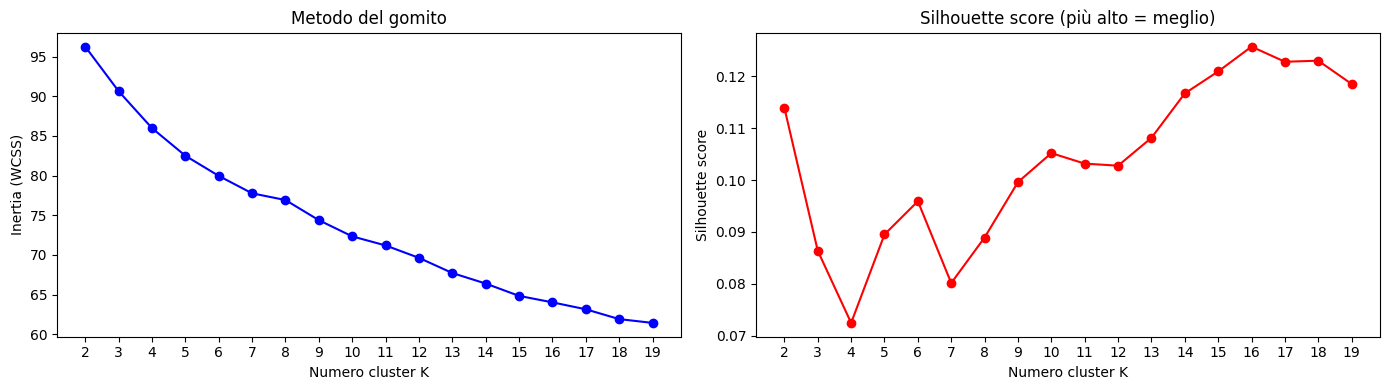

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ============================================================
# CARICA DATI
# ============================================================
embeddings = np.load(drive_path + "embeddings_pca50.npy")        # (501, 50)
df = pd.read_parquet(drive_path + "metadata_key_results.parquet") # paese, periodo, anno, testo

# ============================================================
# STEP 1: SCEGLI IL NUMERO DI CLUSTER (metodo del gomito)
# ============================================================
inertie = []
silhouette = []
K_range = range(2, 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertie.append(km.inertia_)
    silhouette.append(silhouette_score(embeddings, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(K_range, inertie, 'bo-')
ax1.set_xlabel('Numero cluster K')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Metodo del gomito')
ax1.set_xticks(K_range)

ax2.plot(K_range, silhouette, 'ro-')
ax2.set_xlabel('Numero cluster K')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score (più alto = meglio)')
ax2.set_xticks(K_range)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2: CLUSTERING CON K SCELTO
# ============================================================
K_OTTIMALE = 10  # scegli guardando i grafici

km = KMeans(n_clusters=K_OTTIMALE, random_state=42, n_init=10)
df["cluster_kmeans"] = km.fit_predict(embeddings)

In [ ]:
# ============================================================
# STEP 3: ESPLORA I CLUSTER
# ============================================================
for cluster_id in range(K_OTTIMALE):
    subset = df[df["cluster_kmeans"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))


=== CLUSTER 0 (17 documenti) ===
      paese inizio_periodo fine_periodo
El Salvador       Mar 2025     Feb 2026
   Honduras       Apr 2026     Mar 2027
   Honduras       Jun 2021     Aug 2021
El Salvador       Apr 2026     Mar 2027
  Guatemala       Nov 2018     Apr 2019
   Honduras       Mar 2025     Feb 2026
El Salvador       Feb 2018     Aug 2018
El Salvador       Jun 2022     Aug 2022
El Salvador       Jun 2021     Aug 2021
  Guatemala       Feb 2018     Aug 2018
  Guatemala       Jun 2022     Aug 2022
   Honduras       Nov 2018     Apr 2019
  Guatemala       Mar 2025     Feb 2026
  Guatemala       Jun 2021     Aug 2021
El Salvador       Nov 2018     Apr 2019
   Honduras       Feb 2018     Aug 2018
   Honduras       Jun 2022     Aug 2022

=== CLUSTER 1 (35 documenti) ===
      paese inizio_periodo fine_periodo
      Sudan       Jun 2019     Aug 2019
South Sudan       Jan 2015     Mar 2015
South Sudan       Jul 2013     Oct 2013
South Sudan       Apr 2025     Jul 2025
      Sudan 

In [ ]:
import plotly.express as px

# 1. Convertiamo temporaneamente il cluster in stringa (categoria) per forzare i colori discreti
df["cluster_str"] = df["cluster"].astype(str)

# 2. Creiamo il grafico interattivo usando la colonna categorica
fig = px.scatter(df, x="x", y="y",
                 color="cluster_str", # Usa le stringhe per i colori separati
                 hover_data=["paese", "inizio_periodo"],
                 title="Clustering situazioni food insecurity (Esplorazione Interattiva)",
                 category_orders={"cluster_str": sorted(df["cluster_str"].unique())}, # Mantiene l'ordine dei cluster nella legenda
                 opacity=0.7)

# 3. Ottimizziamo le dimensioni e lo stile della legenda
fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="Cluster",
    hovermode="closest",         # Forza l'hover sul punto più vicino
    clickmode="event+select"     # Mantiene l'interazione attiva durante le selezioni
)

# Rende visibili le informazioni di hover SEMPRE, indipendentemente dallo strumento attivo
fig.update_traces(
    hoverinfo="all",
    selector=dict(type='scatter')
)

fig.show()



In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=6, min_samples = 3, metric="manhattan")
df["cluster_hdbscan"] = clusterer.fit_predict(embeddings)
# -1 = outlier (non assegnato a nessun cluster)
print(df["cluster_hdbscan"].value_counts())

cluster_hdbscan
-1     57
 2     34
 3     33
 17    22
 27    20
 25    20
 15    19
 16    17
 1     16
 13    13
 34    13
 33    12
 18    12
 7     11
 14    10
 28    10
 35    10
 24    10
 8     10
 4     10
 21    10
 22     9
 26     9
 11     9
 20     9
 19     9
 30     9
 6      9
 9      9
 31     8
 10     8
 5      7
 29     7
 32     7
 23     7
 12     6
 0      6
Name: count, dtype: int64


In [ ]:
NUM_CLUSTERS = len(df['cluster_hdbscan'].unique())-1

In [ ]:
for cluster_id in range(NUM_CLUSTERS):
    subset = df[df["cluster_hdbscan"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))


=== CLUSTER 0 (6 documenti) ===
      paese inizio_periodo fine_periodo
  Guatemala       Nov 2018     Apr 2019
El Salvador       Feb 2018     Aug 2018
  Guatemala       Feb 2018     Aug 2018
   Honduras       Nov 2018     Apr 2019
El Salvador       Nov 2018     Apr 2019
   Honduras       Feb 2018     Aug 2018

=== CLUSTER 1 (16 documenti) ===
paese inizio_periodo fine_periodo
Yemen       Oct 2023     Feb 2024
Yemen       Jul 2019     Sep 2019
Yemen       Aug 2012     Aug 2012
Yemen       Jan 2022     Dec 2022
Yemen       Jan 2023     Dec 2023
Yemen       May 2025     Feb 2026
Yemen       Jul 2024     Feb 2025
Yemen       Mar 2026     Dec 2026
Yemen       Dec 2013     Feb 2014
Yemen       Oct 2020     Jun 2021
Yemen       Apr 2013     Apr 2013
Yemen       Oct 2022     Dec 2022
Yemen       Mar 2017     Jul 2017
Yemen       Jun 2015     Aug 2015
Yemen       Dec 2018     Jan 2019
Yemen       Sep 2014     Feb 2015

=== CLUSTER 2 (34 documenti) ===
      paese inizio_periodo fine_periodo
 

In [ ]:
df["cluster_hdbscan_str"] = df["cluster_hdbscan"].apply(
    lambda x: "Outliers (Rumore)" if x == -1 else f"Cluster {x}"
)

# Ordiniamo la legenda in modo che gli Outlier siano in fondo
ordine_legenda = sorted([c for c in df["cluster_hdbscan_str"].unique() if c != "Outliers (Rumore)"])
if "Outliers (Rumore)" in df["cluster_hdbscan_str"].unique():
    ordine_legenda.append("Outliers (Rumore)")

# 3. VISUALIZZAZIONE INTERATTIVA (Coordinate X e Y generate da UMAP 2D)
fig = px.scatter(df, x="x", y="y",
                 color="cluster_hdbscan_str",
                 hover_data=["paese", "inizio_periodo"],
                 title="Clustering situazioni food insecurity (HDBSCAN su UMAP)",
                 category_orders={"cluster_hdbscan_str": ordine_legenda},
                 opacity=0.7)

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="HDBSCAN Cluster",
    hovermode="closest"
)

fig.show()


In [ ]:
import hdbscan
import plotly.express as px
import umap


# 2. RIDUZIONE VISIVA SUPERVISIONATA (Per vedere bene i cluster separati)
# Passiamo i cluster 50D dentro fit_transform(..., y=...)
# Questo dice a UMAP di separare visivamente le isole sul grafico in base ai veri cluster
reducer_supervisionato = umap.UMAP(n_components=2, metric="cosine", random_state=42)
embeddings_2d_supervisionato = reducer_supervisionato.fit_transform(
    embeddings,
    y=df["cluster_hdbscan"] # La chiave magica: guida la separazione visiva
)

# Aggiorniamo le coordinate del grafico
df["x_visiva"] = embeddings_2d_supervisionato[:, 0]
df["y_visiva"] = embeddings_2d_supervisionato[:, 1]

# 3. PREPARAZIONE DELLE ETICHETTE

ordine_legenda = sorted([c for c in df["cluster_hdbscan_str"].unique() if c != "Outliers (Rumore)"])
if "Outliers (Rumore)" in df["cluster_hdbscan_str"].unique():
    ordine_legenda.append("Outliers (Rumore)")

# 4. VISUALIZZAZIONE DEL CLUSTERING 50D SU SPAZIO SEPARATO
fig = px.scatter(df, x="x_visiva", y="y_visiva",
                 color="cluster_hdbscan_str",
                 hover_data=["paese", "inizio_periodo"],
                 title="Visualizzazione Separata del Clustering effettuato a 50D (UMAP Supervisionato)",
                 category_orders={"cluster_hdbscan_str": ordine_legenda},
                 opacity=0.7)

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="Veri Cluster 50D",
    hovermode="closest"
)

fig.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import numpy as np

# Assicurati che i nomi delle colonne dei tuoi cluster siano corretti
# df["cluster_kmeans"] -> i tuoi vecchi cluster KMeans (es: K=4)
# df["cluster_hdbscan"] -> i tuoi nuovi cluster HDBSCAN a 50D

# --- FILTRO PER HDBSCAN (Escludiamo gli outlier -1 dalle metriche di distanza) ---
df_filtered = df[df["cluster_hdbscan"] != -1]
embeddings_filtered = embeddings_reduced[df["cluster_hdbscan"] != -1]

# --- CALCOLO METRICHE K-MEANS ---
km_sil = silhouette_score(embeddings_reduced, df["cluster_kmeans"])
km_ch = calinski_harabasz_score(embeddings_reduced, df["cluster_kmeans"])
km_db = davies_bouldin_score(embeddings_reduced, df["cluster_kmeans"])

# --- CALCOLO METRICHE HDBSCAN ---
hdb_sil = silhouette_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_ch = calinski_harabasz_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_db = davies_bouldin_score(embeddings_filtered, df_filtered["cluster_hdbscan"])

# --- COSTRUZIONE TABELLA DI CONFRONTO ---
confronto_data = {
    "Metrica": [
        "Numero di Cluster trovati",
        "Percentuale Rumore / Outliers",
        "Silhouette Score (Più alto = meglio)",
        "Calinski-Harabasz Index (Più alto = meglio)",
        "Davies-Bouldin Index (Più basso = meglio)"
    ],
    "K-Means": [
        df["cluster_kmeans"].nunique(),
        "0.0% (Forza tutti i punti)",
        f"{km_sil:.3f}",
        f"{km_ch:.1f}",
        f"{km_db:.3f}"
    ],
    "HDBSCAN": [
        df_filtered["cluster_hdbscan"].nunique(),
        f"{(df['cluster_hdbscan'] == -1).sum() / len(df) * 100:.1f}%",
        f"{hdb_sil:.3f}",
        f"{hdb_ch:.1f}",
        f"{hdb_db:.3f}"
    ]
}

df_confronto = pd.DataFrame(confronto_data)
print("\n=== TABELLA COMPARATIVA DEL CLUSTERING A 50D ===")
display(df_confronto)



=== TABELLA COMPARATIVA DEL CLUSTERING A 50D ===


,Metrica,K-Means,HDBSCAN
0,Numero di Cluster trovati,16,36
1,Percentuale Rumore / Outliers,0.0% (Forza tutti i punti),11.5%
2,Silhouette Score (Più alto = meglio),0.535,0.748
3,Calinski-Harabasz Index (Più alto = meglio),547.2,2293.3
4,Davies-Bouldin Index (Più basso = meglio),0.696,0.381


In [ ]:
# 1. DEFINIZIONE DELLE GRIGLIE (Popolate correttamente per il tuo dataset)
grid_min_cluster = [3, 4, 5, 6, 7, 8, 10]
grid_min_samples = [1, 2, 3, 5]
grid_metrics = ['euclidean', 'manhattan']

risultati = []

print("Esecuzione dell'ottimizzazione in corso...")

for m_cluster in grid_min_cluster:
    for m_samples in grid_min_samples:
        for metrica in grid_metrics:

            # CORREZIONE: gen_min_span_tree=True è obbligatorio per calcolare la stabilità
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=m_cluster,
                min_samples=m_samples,
                metric=metrica,
                gen_min_span_tree=True
            )
            labels = clusterer.fit_predict(embeddings_reduced)

            # Calcola il numero di cluster (escludendo il rumore -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Calcola la percentuale di rumore
            percentuale_rumore = (labels == -1).sum() / len(labels) * 100

            # Calcola le metriche solo se ci sono almeno 2 cluster reali
            if n_clusters >= 2 and percentuale_rumore < 90:
                mask = labels != -1
                sil_score = silhouette_score(embeddings_reduced[mask], labels[mask])

                # Ora questo attributo non fallirà più
                dbcv_approx = clusterer.relative_validity_
            else:
                sil_score = np.nan
                dbcv_approx = np.nan

            risultati.append({
                "min_cluster_size": m_cluster,
                "min_samples": m_samples,
                "metric": metrica,
                "Num_Cluster": n_clusters,
                "Perc_Rumore_%": round(percentuale_rumore, 1),
                "Silhouette_Pura": round(sil_score, 3) if pd.notnull(sil_score) else np.nan,
                "Stabilita_Media": round(dbcv_approx, 3) if pd.notnull(dbcv_approx) else np.nan
            })

# Converte in DataFrame e ordina per Silhouette più alta
df_tuning = pd.DataFrame(risultati).dropna()
df_tuning = df_tuning.sort_values(by="Silhouette_Pura", ascending=False).reset_index(drop=True)

print("\n=== TOP 10 CONFIGURAZIONI MIGLIORI ===")
display(df_tuning.head(10))


Esecuzione dell'ottimizzazione in corso...

=== TOP 10 CONFIGURAZIONI MIGLIORI ===


,min_cluster_size,min_samples,metric,Num_Cluster,Perc_Rumore_%,Silhouette_Pura,Stabilita_Media
0,6,3,manhattan,36,11.5,0.748,0.488
1,5,3,manhattan,39,10.3,0.746,0.493
2,3,3,manhattan,42,10.7,0.742,0.497
3,4,3,manhattan,41,10.3,0.740,0.471
4,5,2,manhattan,40,8.7,0.740,0.528
5,7,3,manhattan,34,12.7,0.739,0.488
6,3,3,euclidean,42,9.5,0.738,0.549
7,6,2,manhattan,38,10.7,0.737,0.522
8,5,3,euclidean,40,9.9,0.736,0.535
9,4,3,euclidean,40,9.9,0.736,0.535


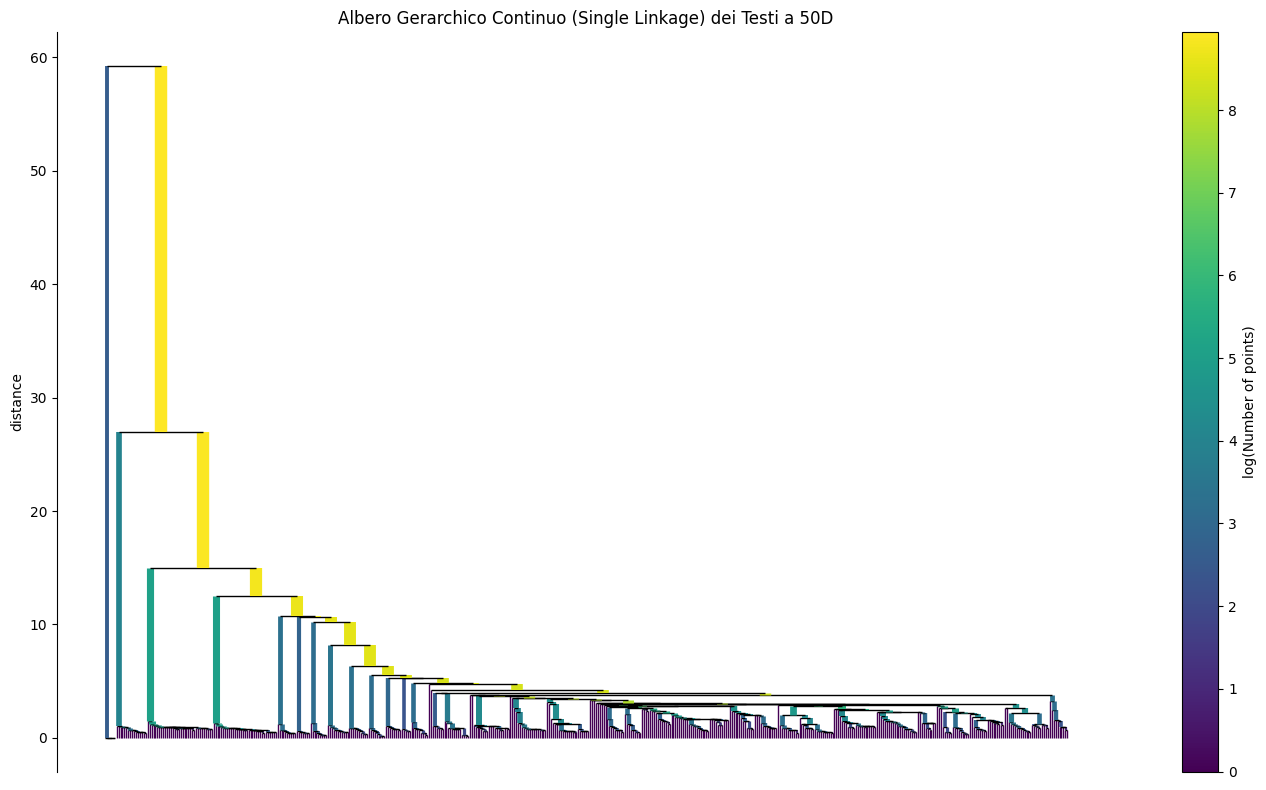

In [ ]:
import matplotlib.pyplot as plt
import hdbscan

# 1. Configura e allena il modello (Riga 0 della tua Grid Search)
clusterer_definitivo = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=3,
    metric='manhattan',
    gen_min_span_tree=True # Obbligatorio
)
clusterer_definitivo.fit(embeddings_reduced)

# 2. DISEGNO DELL'ALBERO GERARCHICO COMPLETO
plt.figure(figsize=(14, 8))

# Questo metodo non si blocca su Colab e mostra il dendrogramma continuo
clusterer_definitivo.single_linkage_tree_.plot(cmap='viridis', colorbar=True)

plt.title("Albero Gerarchico Continuo (Single Linkage) dei Testi a 50D")
plt.tight_layout()
plt.show()



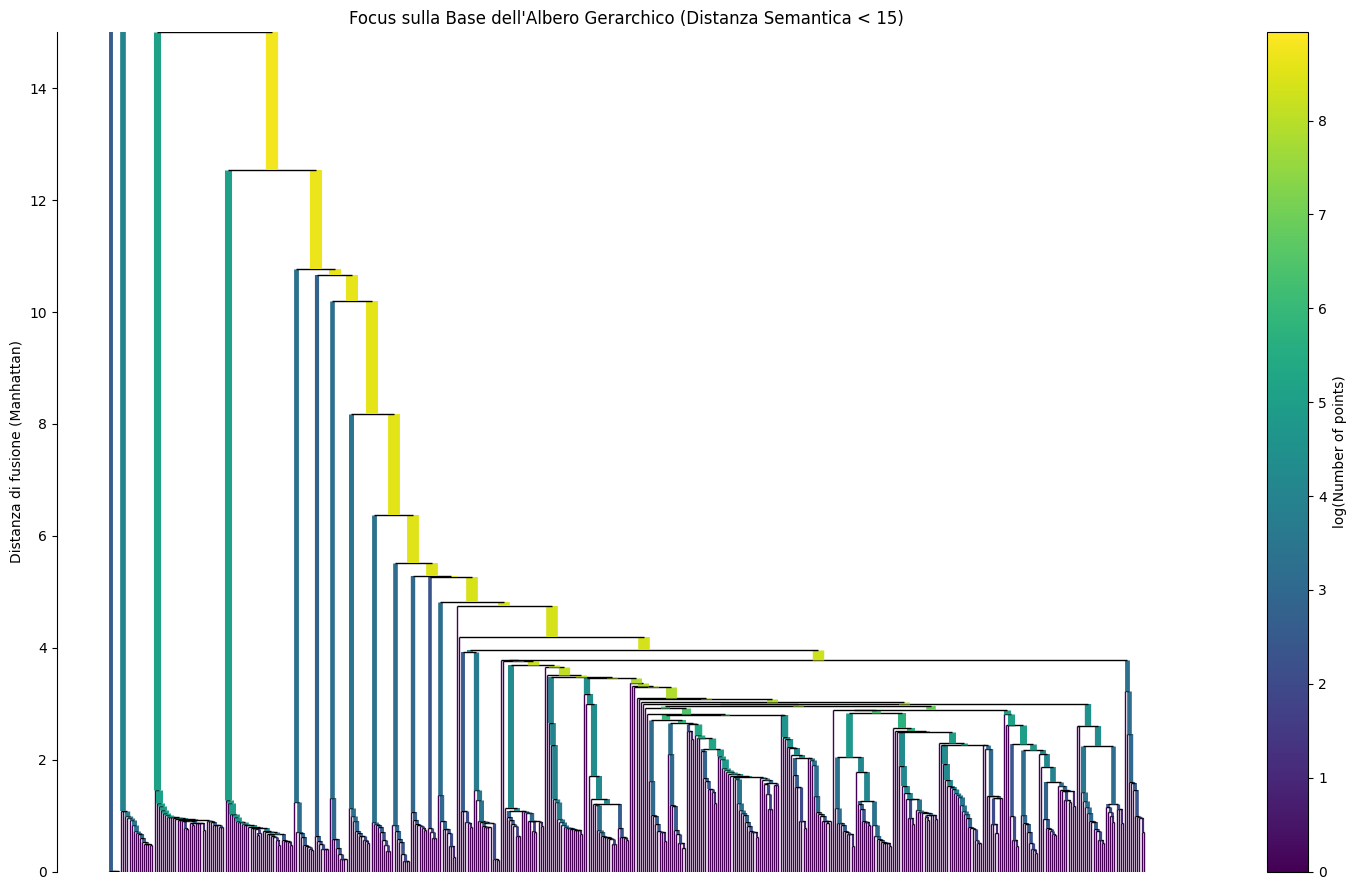

In [ ]:
# 1. Allineamento del modello (stessi parametri scelti nella Grid Search)
clusterer_definitivo = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=3,
    metric='manhattan',
    gen_min_span_tree=True
)
clusterer_definitivo.fit(embeddings_reduced)

# 2. Generazione del grafico con ZOOM programmato
plt.figure(figsize=(15, 9)) # Leggermente più grande per aumentare il dettaglio visivo

# Disegna l'albero gerarchico completo
clusterer_definitivo.single_linkage_tree_.plot(cmap='viridis', colorbar=True)

# ZOOM LOGICO: Taglia la parte alta vuota dell'albero e si concentra sulla base
plt.ylim(0, 15)

plt.title("Focus sulla Base dell'Albero Gerarchico (Distanza Semantica < 15)")
plt.ylabel("Distanza di fusione (Manhattan)")
plt.tight_layout()
plt.show()


In [ ]:
# 1. Recupera i punteggi di stabilità direttamente dal modello principale
# (Utilizza l'attributo corretto cluster_persistence_ dell'oggetto HDBSCAN)
punteggi_stabilita = clusterer_definitivo.cluster_persistence_

# 2. Conta quanti documenti appartengono a ciascun cluster reale (escluso il rumore -1)
conteggio_punti = df["cluster_hdbscan"].value_counts()

# 3. Costruisci il DataFrame riassuntivo
report_stabilita = []

# Iteriamo sui punteggi usando l'indice progressivo del cluster
for cluster_id, stabilita in enumerate(punteggi_stabilita):
    num_documenti = conteggio_punti.get(cluster_id, 0)

    # Estrae i paesi principali per dare un contesto semantico immediato al cluster
    paesi_top = df[df["cluster_hdbscan"] == cluster_id]["paese"].value_counts().head(2).index.tolist()
    paesi_str = ", ".join(paesi_top) if paesi_top else "N/A"

    report_stabilita.append({
        "Cluster ID": f"Cluster {cluster_id}",
        "Punteggio Stabilità": round(stabilita, 5),
        "Numero Documenti": num_documenti,
        "Paesi Rappresentativi": paesi_str
    })

# Trasforma in DataFrame e ordina dal cluster più stabile a quello meno stabile
df_stabilita = pd.DataFrame(report_stabilita).sort_values(by="Punteggio Stabilità", ascending=False).reset_index(drop=True)

print("\n=== CLASSIFICA DI STABILITÀ DEI CLUSTER (Ordinata per Excess of Mass) ===")
display(df_stabilita)




=== CLASSIFICA DI STABILITÀ DEI CLUSTER (Ordinata per Excess of Mass) ===


,Cluster ID,Punteggio Stabilità,Numero Documenti,Paesi Rappresentativi
0,Cluster 0,1.00000,6,"Guatemala, El Salvador"
1,Cluster 6,0.00057,9,"Lebanon, Yemen"
2,Cluster 5,0.00049,7,Gaza Strip
3,Cluster 4,0.00048,10,Sudan
4,Cluster 9,0.00045,9,Haiti
5,Cluster 1,0.00041,16,Yemen
6,Cluster 7,0.00036,11,"El Salvador, Honduras"
7,Cluster 8,0.00034,10,Lesotho
8,Cluster 3,0.00032,33,"Somalia, Ethiopia"
9,Cluster 11,0.00029,9,"El Salvador, Guatemala"


In [ ]:
# Stampa i testi del Cluster 0 (Massima stabilità)
print("=== COSA C'È DIETRO IL CLUSTER 0 (Stabilità 1.0) ===")
testi_c0 = df[df["cluster_hdbscan"] == 0]["testo"].head(2)
for idx, t in enumerate(testi_c0):
    print(f"\nDocumento {idx+1}:")
    print(t[:2000] + "...\n") # Mostra i primi 400 caratteri

print("-" * 50)

# Stampa i testi del Cluster 6
print("=== COSA C'È DIETRO IL CLUSTER 6")
testi_c6 = df[df["cluster_hdbscan"] == 6]["testo"].head(2)
for idx, t in enumerate(testi_c6):
    print(f"\nDocumento {idx+1}:")
    print(t[:2000] + "...\n")


=== COSA C'È DIETRO IL CLUSTER 0 (Stabilità 1.0) ===

Documento 1:
The Tri-national Border Federation of Río Lempa (Mancomunitad Trinacional Fronteriza Río Lempa) is a Public Law entity, located in the Trifinio Region and composed of municipalities of three countries of El Salvador, Guatemala and Honduras. This report contains the results of the analysis carried out in February 2018 in seven microregions of the Tri-national Border Federation of Río Lempa according to the approach of the IPC Acute Food Insecurity scale, which aims to classify the severity and define the phase of food insecurity of the territories and / or communities making use of information of various kinds in order to support evidence-based decisions. The IPC helps resolve concerns about which areas are facing food insecurity, who it affects, how many people, and how serious is the situation, guiding what should be done and when.
In the analyzed period (November 2018 – January 2019), a fourth of the population analyz

In [ ]:
import spacy
from tqdm import tqdm  # Per vedere il progresso della pulizia semantica

# ============================================================
# INIZIALIZZAZIONE SPACY (NER)
# ============================================================
# Carica il modello per la lingua inglese. Se i tuoi testi fossero in italiano,
# usa "it_core_news_sm" e assicurati di averlo installato.
try:
    nlp = spacy.load("en_core_web_sm")
    nlp.select_pipes(enable=["tok2vec", "tagger", "ner"])
except OSError:
    # Se non è presente su Colab, lo scarica in automatico
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

# Disattiviamo i componenti non necessari per velocizzare il processo di pulizia
nlp.select_pipes(enable=["ner"])

def anonimizza_testo_crisi(testo_input):
    """
    Rimuove dal testo i nomi di luoghi geografici (GPE) e riferimenti
    temporali (DATE) per evitare bias nel clustering.
    """
    doc = nlp(testo_input)
    # GPE = Geopolitical Entity (paesi, città, stati)
    # DATE = Riferimenti temporali (mesi, anni, date assolute)

    tokens_puliti = []

    for token in doc:
        # 1. Estraiamo il testo normalizzato in minuscolo per i controlli
        testo_lower = token.text.lower().strip()

        # Saltiamo i token vuoti
        if not testo_lower:
            continue

        if token.ent_type_ == 'GPE':
            continue

        # 2. FILTRO 1: Rimuove i riferimenti temporali (DATE) riconosciuti dal NER
        if token.ent_type_ == 'DATE':
            continue

        # 3. FILTRO 2: Rimuove TUTTI i Nomi Propri (Paesi, Città, Nomi di fazioni, Mesi con la maiuscola)
        if token.pos_ == 'PROPN':
            continue

        # Se supera tutti i filtri, il token è un termine tecnico/comune e viene salvato
        tokens_puliti.append(token.text)

    return " ".join(tokens_puliti)

# ============================================================
# GENERA EMBEDDING ANONIMIZZATI
# ============================================================
files = [f for f in os.listdir(TESTO_DIR) if f.endswith(".txt")]
print(f"Trovati {len(files)} file...")

testi = []
testi_anonimizzati = [] # Conterrà il testo privato di geografia e date
metadata_list = []

print("Fase 1: Lettura, pulizia intestazioni e anonimizzazione geografica...")
# Usiamo tqdm per monitorare il ciclo, dato che Spacy richiede qualche secondo in più
for nome_file in tqdm(files):
    path = os.path.join(TESTO_DIR, nome_file)
    with open(path, "r", encoding="utf-8") as f:
        testo = f.read()

    testo_pulito = re.sub(r'^.*?={40}\n\n', '', testo, flags=re.DOTALL).strip()
    if not testo_pulito:
        continue

    # Applica il filtro Spacy per rimuovere paesi e date
    testo_senza_geografia = anonimizza_testo_crisi(testo_pulito)

    # Se il filtro dovesse svuotare completamente il testo (raro), saltiamo
    if not testo_senza_geografia.strip():
        continue

    testi.append(testo_pulito) # Manteniamo il testo originale nel DataFrame per la lettura umana
    testi_anonimizzati.append(testo_senza_geografia) # Questo andrà al modello di embedding
    metadata_list.append(estrai_metadata(nome_file))

print(f"\nFase 2: Generazione embedding per {len(testi_anonimizzati)} documenti...")
# IMPORTANTE: Passiamo 'testi_anonimizzati' al modello, non quelli originali
embeddings2 = model.encode(testi_anonimizzati, normalize_embeddings=True, show_progress_bar=True)
print(f"Embedding generati con successo: shape {embeddings2.shape}")


Trovati 497 file...
Fase 1: Lettura, pulizia intestazioni e anonimizzazione geografica...


100%|██████████| 497/497 [00:13<00:00, 36.36it/s]


Fase 2: Generazione embedding per 497 documenti...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding generati con successo: shape (497, 384)


In [ ]:
# verifica similarità embedding prodotti a 384 dim

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Scegli l'indice del documento "Ancora" (es. il documento numero 10, cambialo a piacimento)
idx_ancora = 10

# 2. Calcola la similarità coseno tra il documento scelto e TUTTI gli altri nel dataset
# Lavoriamo sullo spazio a 50 dimensioni ridotte
vettore_ancora = embeddings[idx_ancora].reshape(1, -1)
similarita = cosine_similarity(vettore_ancora, embeddings).flatten()

# 3. Prendi gli indici dei primi 6 documenti più simili (il primo sarà il documento stesso, con similarità 1.0)
# ordinamento ascendente, prendiamo gli ultimi 6 elementi e invertiamo l'ordine
indici_top5 = np.argsort(similarita)[-6:-1][::-1]

# 4. STAMPA IL CONFRONTO QUALITATIVO
print("=" * 80)
print(f"DOCUMENTO ANCORA (Indice {idx_ancora})")
print(f"Paese: {df.iloc[idx_ancora]['paese']} | Periodo: {df.iloc[idx_ancora]['inizio_periodo']}")
print(f"Testo Originale (estratto): {df.iloc[idx_ancora]['testo'][:350]}...")
print("=" * 80)
print("\n--- I 5 DOCUMENTI PIÙ VICINI NELLO SPAZIO A 50 DIMENSIONI ---")

for i, idx_vicino in enumerate(indici_top5, 1):
    score = similarita[idx_vicino]
    print(f"\n[Vicino #{i}] - Indice {idx_vicino} | Cosine Similarity: {score:.4f}")
    print(f"Paese: {df.iloc[idx_vicino]['paese']} | Periodo: {df.iloc[idx_vicino]['inizio_periodo']}")
    print(f"Testo Originale (estratto): {df.iloc[idx_vicino]['testo'][:350]}...")
    print("-" * 60)

DOCUMENTO ANCORA (Indice 10)
Paese: Lebanon | Periodo: May 2023
Testo Originale (estratto): The ongoing economic and financial crisis in Lebanon, which began in October 2019, has greatly worsened the food security situation in the country. This crisis has particularly affected a vulnerable population that includes Lebanese residents, Syrian refugees, Palestine refugees in Lebanon, Palestine refugees from Syria, as well as other refugee gr...

--- I 5 DOCUMENTI PIÙ VICINI NELLO SPAZIO A 50 DIMENSIONI ---

[Vicino #1] - Indice 105 | Cosine Similarity: 0.9609
Paese: Lebanon | Periodo: Oct 2023
Testo Originale (estratto): The ongoing economic crisis continues to affect Lebanon’s food security situation. This crisis has particularly affected a vulnerable population that includes Lebanese residents, Syrian refugees, Palestine refugees in Lebanon (PRL) and Palestine refugees from Syria (PRS).
In the current period, between October 2023 and March 2024, about 1.05 millio...
--------------------

In [ ]:
from scipy.stats import spearmanr
from tqdm import tqdm

# --- 1. CALCOLO MATRICI DI SIMILARITÀ ---
# (Assicurati che 'embeddings' siano quelli originali e 'embeddings_reduced' quelli a 50D)
print("Calcolo delle matrici di similarità coseno...")
sim_originale = cosine_similarity(embeddings)
sim_compressa = cosine_similarity(embeddings_reduced)

# --- 2. VERIFICA GLOBALE: CORRELAZIONE DI SPEARMAN ---
# Estraiamo solo il triangolo superiore delle matrici (escludendo la diagonale principale)
indici_sup = np.triu_indices(len(df), k=1)
vett_sim_orig = sim_originale[indici_sup]
vett_sim_comp = sim_compressa[indici_sup]

correlazione, _ = spearmanr(vett_sim_orig, vett_sim_comp)

# --- 3. VERIFICA LOCALE: INTERSEZIONE DEI TOP 10 VICINI ---
N_vicini = 10
intersezioni_totali = []

for idx in range(len(df)):
    # Trova i 10 vicini più simili nello spazio originale (escluso se stesso)
    vicini_orig = np.argsort(sim_originale[idx])[:-1-N_vicini:-1]

    # Trova i 10 vicini più simili nello spazio compresso (escluso se stesso)
    vicini_comp = np.argsort(sim_compressa[idx])[:-1-N_vicini:-1]

    # Calcola quanti elementi hanno in comune
    comuni = len(set(vicini_orig).intersection(set(vicini_comp)))
    intersezioni_totali.append(comuni)

percentuale_mantenimento = (np.mean(intersezioni_totali) / N_vicini) * 100

# --- 4. REPORT FINALE ---
print("\n================ REPORT DI COMPRESSIONE GEOMETRICA ================")
print(f"1. Correlazione d'ordine globale (Spearman): {correlazione:.4f}")
print(f"2. Conservazione locale dei primi {N_vicini} vicini: {percentuale_mantenimento:.1f}%")
print("====================================================================")

if correlazione > 0.80 and percentage_maintenance > 75:
    print("Esito: La compressione con UMAP è ECCELLENTE. La struttura semantica è intatta.")
elif correlazione > 0.60:
    print("Esito: La compressione è BUONA. Ci sono lievi distorsioni globali, ma i vicini locali sono coerenti.")
else:
    print("Esito: Attenzione, la riduzione a 50D ha introdotto un forte stress geometrico.")


Calcolo delle matrici di similarità coseno...

================ REPORT DI COMPRESSIONE GEOMETRICA ================
1. Correlazione d'ordine globale (Spearman): 0.2407
2. Conservazione locale dei primi 10 vicini: 61.7%
Esito: Attenzione, la riduzione a 50D ha introdotto un forte stress geometrico.
